# Filter Visualization & Compression

1. Re-train best classifier (LogReg + full features + combined train data)
2. На каждой test-странице прогоняем classifier на её candidates
3. Удаляем junk-predicted regions (top-down: всё subtree)
4. Визуализируем: original | overlay (red = junk) | masked (filtered)
5. Считаем aggregate compression
6. **Сохраняем все изображения в `figures/`**

In [15]:
import json
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, '.')
import filter_apply as fa
import filter_visualize as fv

import importlib
importlib.reload(fa)
importlib.reload(fv)

# Где сохраняются все картинки
FIGURES_DIR = Path('figures')
PER_PAGE_DIR = FIGURES_DIR / 'per_page'
COMPARISONS_DIR = FIGURES_DIR / 'comparisons'
STATS_DIR = FIGURES_DIR / 'stats'
for d in (PER_PAGE_DIR, COMPARISONS_DIR, STATS_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f'Figures will be saved to: {FIGURES_DIR.resolve()}')

Figures will be saved to: C:\Users\70133\VS_Code_Projects\jarvis-core\notebooks\webui\training\figures


## 1. Train best model + load test split

In [16]:
model, artifacts = fa.train_best_model()

with open(fa.DATA_DIR / 'splits.json', encoding='utf-8') as f:
    splits_data = json.load(f)
splits = splits_data['splits']
topic_map = splits_data['page_topic']

test_pages = sorted([pid for pid, sp in splits.items() if sp == 'test'])
print(f'Test pages: {len(test_pages)}')

candidates_by_page = fa.load_candidates_index()
print(f'Pages with candidates: {len(candidates_by_page)}')

Loading train features...
X_train shape: (4385, 20031), y_train: junk=1816/4385
Model trained.
Test pages: 42
Pages with candidates: 400


## 2. Predictions + compression for ALL test pages

In [17]:
all_results = []

for pid in test_pages:
    page_cands = candidates_by_page.get(pid, [])
    if not page_cands:
        continue
    preds = fa.predict_for_page(page_cands, model, artifacts)
    ax_data = fa.load_page_axtree(pid)
    if ax_data is None:
        continue
    comp = fa.compute_compression(preds, ax_data)
    all_results.append({
        'page_id': pid,
        'topic': topic_map.get(pid, 'unknown'),
        'predictions': preds,
        'ax_data': ax_data,
        'compression': comp,
    })

print(f'Processed {len(all_results)} test pages')

Processed 42 test pages


## 3. SAVE all per-page images (original / overlay / filtered)

Для каждой test-страницы сохраняется 3 PNG в `figures/per_page/`:
- `<page_id>_<topic>_<compression>%_original.png`
- `<page_id>_<topic>_<compression>%_overlay.png`
- `<page_id>_<topic>_<compression>%_filtered.png`

In [18]:
saved_count = 0
for r in all_results:
    page_dir = r['ax_data']['page_dir']
    screen_path = fa.find_screenshot(page_dir)
    if screen_path is None:
        continue
    img = Image.open(screen_path).convert('RGB')
    junk_bboxes = [p['candidate']['bbox'] for p in r['predictions'] if p['predicted_junk']]

    overlay = fv.shade_regions(img, junk_bboxes, color=(255, 0, 0), alpha=100)
    overlay = fv.draw_outlines(overlay, junk_bboxes, color=(220, 0, 0), width=4)
    masked = fv.mask_regions(img, junk_bboxes, fill_color=(255, 255, 255), alpha=255)

    cr = int(round(r['compression']['compression_ratio'] * 100))
    base = f'{r["page_id"]}_{r["topic"]}_cr{cr:03d}'
    img.save(PER_PAGE_DIR / f'{base}_original.png')
    overlay.save(PER_PAGE_DIR / f'{base}_overlay.png')
    masked.save(PER_PAGE_DIR / f'{base}_filtered.png')
    saved_count += 1

print(f'Saved {saved_count} pages × 3 images each = {saved_count*3} files in {PER_PAGE_DIR}')

Saved 42 pages × 3 images each = 126 files in figures\per_page


## 4. SAVE side-by-side comparison images (PIL, full resolution)

Для каждой страницы — combined original | overlay | filtered как один большой PNG. Высокое разрешение, удобно вставлять в thesis.

In [19]:
from PIL import ImageDraw, ImageFont

def make_3way_comparison(img, overlay, masked, title):
    """3 images side-by-side с подписью."""
    pad = 10
    label_h = 40
    h = max(img.height, overlay.height, masked.height) + label_h
    w = img.width + overlay.width + masked.width + 2*pad
    out = Image.new('RGB', (w, h), (240, 240, 240))
    out.paste(img, (0, label_h))
    out.paste(overlay, (img.width + pad, label_h))
    out.paste(masked, (img.width + overlay.width + 2*pad, label_h))
    draw = ImageDraw.Draw(out)
    try:
        font = ImageFont.truetype('arial.ttf', 18)
    except (OSError, IOError):
        font = ImageFont.load_default()
    draw.text((10, 10), f'Original — {title}', fill=(0, 0, 0), font=font)
    draw.text((img.width + pad + 10, 10), 'Overlay (red = junk)', fill=(180, 0, 0), font=font)
    draw.text((img.width + overlay.width + 2*pad + 10, 10), 'After filter', fill=(0, 100, 0), font=font)
    return out

saved_comp = 0
for r in all_results:
    page_dir = r['ax_data']['page_dir']
    screen_path = fa.find_screenshot(page_dir)
    if screen_path is None:
        continue
    img = Image.open(screen_path).convert('RGB')
    junk_bboxes = [p['candidate']['bbox'] for p in r['predictions'] if p['predicted_junk']]
    overlay = fv.shade_regions(img, junk_bboxes, color=(255, 0, 0), alpha=100)
    overlay = fv.draw_outlines(overlay, junk_bboxes, color=(220, 0, 0), width=4)
    masked = fv.mask_regions(img, junk_bboxes, fill_color=(255, 255, 255), alpha=255)

    cr = r['compression']['compression_ratio'] * 100
    title = f'{r["page_id"]} ({r["topic"]}, {cr:.0f}% removed)'
    combined = make_3way_comparison(img, overlay, masked, title)

    cr_int = int(round(cr))
    combined.save(COMPARISONS_DIR / f'{r["page_id"]}_{r["topic"]}_cr{cr_int:03d}_3way.png')
    saved_comp += 1

print(f'Saved {saved_comp} comparison PNGs in {COMPARISONS_DIR}')

Saved 42 comparison PNGs in figures\comparisons


## 5. Aggregate compression statistics + save histograms

=== Aggregate compression on 42 test pages ===
  Avg AXTree nodes per page: 538.3 (median 491)
  Avg removed nodes per page: 215.8
  Avg kept nodes per page: 322.5
  Avg compression ratio: 40.5%
  Median compression ratio: 36.9%

  Total nodes across all test pages: 22608
  Total removed: 9062
  Aggregate compression: 40.1%

  Avg candidates predicted as junk per page: 6.7 / 18.4


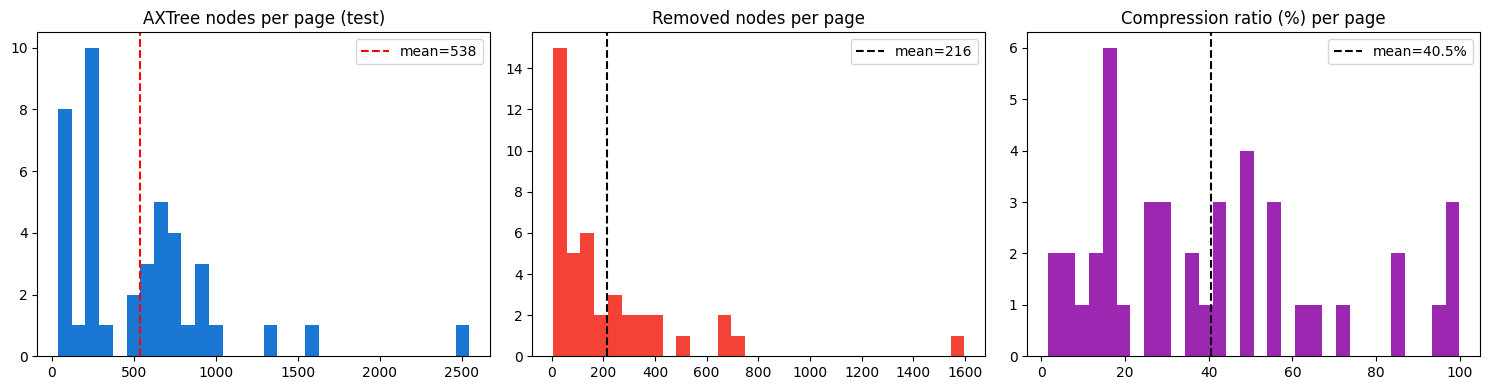

Saved stats to figures\stats\compression_stats.json


In [20]:
total_nodes = [r['compression']['n_total_nodes'] for r in all_results]
removed_nodes = [r['compression']['n_removed_nodes'] for r in all_results]
kept_nodes = [r['compression']['n_kept_nodes'] for r in all_results]
ratios = [r['compression']['compression_ratio'] for r in all_results]
junk_pred_counts = [r['compression']['n_junk_candidates'] for r in all_results]
total_cand_counts = [r['compression']['n_total_candidates'] for r in all_results]

print(f'=== Aggregate compression on {len(all_results)} test pages ===')
print(f'  Avg AXTree nodes per page: {np.mean(total_nodes):.1f} (median {np.median(total_nodes):.0f})')
print(f'  Avg removed nodes per page: {np.mean(removed_nodes):.1f}')
print(f'  Avg kept nodes per page: {np.mean(kept_nodes):.1f}')
print(f'  Avg compression ratio: {np.mean(ratios)*100:.1f}%')
print(f'  Median compression ratio: {np.median(ratios)*100:.1f}%')
print()
print(f'  Total nodes across all test pages: {sum(total_nodes)}')
print(f'  Total removed: {sum(removed_nodes)}')
print(f'  Aggregate compression: {sum(removed_nodes)/sum(total_nodes)*100:.1f}%')
print()
print(f'  Avg candidates predicted as junk per page: {np.mean(junk_pred_counts):.1f} / {np.mean(total_cand_counts):.1f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(total_nodes, bins=30, color='#1976d2')
axes[0].set_title('AXTree nodes per page (test)')
axes[0].axvline(np.mean(total_nodes), color='red', linestyle='--', label=f'mean={np.mean(total_nodes):.0f}')
axes[0].legend()
axes[1].hist(removed_nodes, bins=30, color='#f44336')
axes[1].set_title('Removed nodes per page')
axes[1].axvline(np.mean(removed_nodes), color='black', linestyle='--', label=f'mean={np.mean(removed_nodes):.0f}')
axes[1].legend()
axes[2].hist([r*100 for r in ratios], bins=30, color='#9c27b0')
axes[2].set_title('Compression ratio (%) per page')
axes[2].axvline(np.mean(ratios)*100, color='black', linestyle='--', label=f'mean={np.mean(ratios)*100:.1f}%')
axes[2].legend()
plt.tight_layout()
plt.savefig(STATS_DIR / 'compression_histograms.png', dpi=120, bbox_inches='tight')
plt.show()

# Save raw stats as JSON for thesis text
stats = {
    'n_test_pages': len(all_results),
    'avg_nodes_per_page': float(np.mean(total_nodes)),
    'median_nodes_per_page': float(np.median(total_nodes)),
    'avg_removed_per_page': float(np.mean(removed_nodes)),
    'avg_kept_per_page': float(np.mean(kept_nodes)),
    'avg_compression_ratio': float(np.mean(ratios)),
    'median_compression_ratio': float(np.median(ratios)),
    'aggregate_compression': float(sum(removed_nodes) / sum(total_nodes)),
    'per_page': [
        {'page_id': r['page_id'], 'topic': r['topic'],
         'n_total_nodes': r['compression']['n_total_nodes'],
         'n_removed_nodes': r['compression']['n_removed_nodes'],
         'compression_ratio': r['compression']['compression_ratio'],
         'n_junk_candidates': r['compression']['n_junk_candidates'],
         'n_total_candidates': r['compression']['n_total_candidates']}
        for r in all_results
    ]
}
with open(STATS_DIR / 'compression_stats.json', 'w', encoding='utf-8') as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)
print(f'Saved stats to {STATS_DIR / "compression_stats.json"}')

## 6. Compression by topic + save

topic         n_pages   mean_ratio     median
tutorial           16        48.2%      41.0%
news                9        31.6%      25.6%
terms               7        33.4%      27.6%
list                6        45.1%      39.3%
bare                2        31.6%      31.6%
other               2        39.4%      39.4%


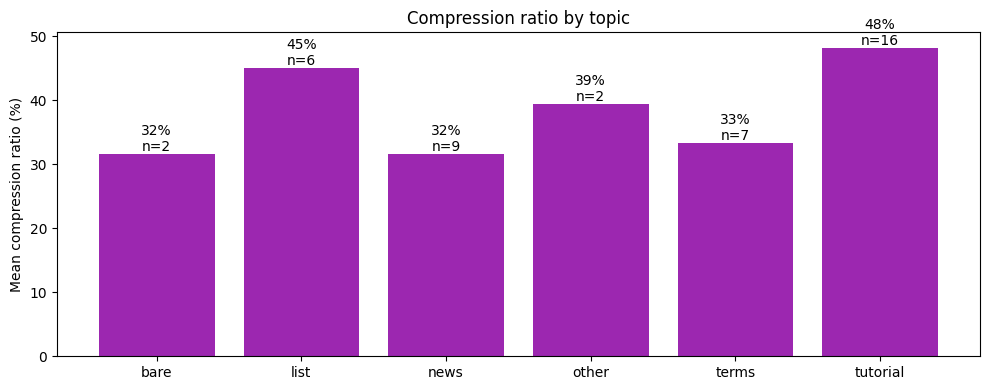

In [21]:
by_topic = defaultdict(list)
for r in all_results:
    by_topic[r['topic']].append(r['compression']['compression_ratio'])

print(f'{"topic":<12s} {"n_pages":>8s} {"mean_ratio":>12s} {"median":>10s}')
for t, vals in sorted(by_topic.items(), key=lambda x: -len(x[1])):
    print(f'{t:<12s} {len(vals):>8d} {np.mean(vals)*100:>11.1f}% {np.median(vals)*100:>9.1f}%')

topics_sorted = sorted(by_topic.keys())
means = [np.mean(by_topic[t]) * 100 for t in topics_sorted]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(topics_sorted, means, color='#9c27b0')
for i, m in enumerate(means):
    ax.text(i, m, f'{m:.0f}%\nn={len(by_topic[topics_sorted[i]])}', ha='center', va='bottom')
ax.set_ylabel('Mean compression ratio (%)')
ax.set_title('Compression ratio by topic')
plt.tight_layout()
plt.savefig(STATS_DIR / 'compression_by_topic.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Visual demos in notebook (8 random pages)

Inline display для быстрой инспекции. Все полные изображения уже сохранены в `figures/per_page/` и `figures/comparisons/`.

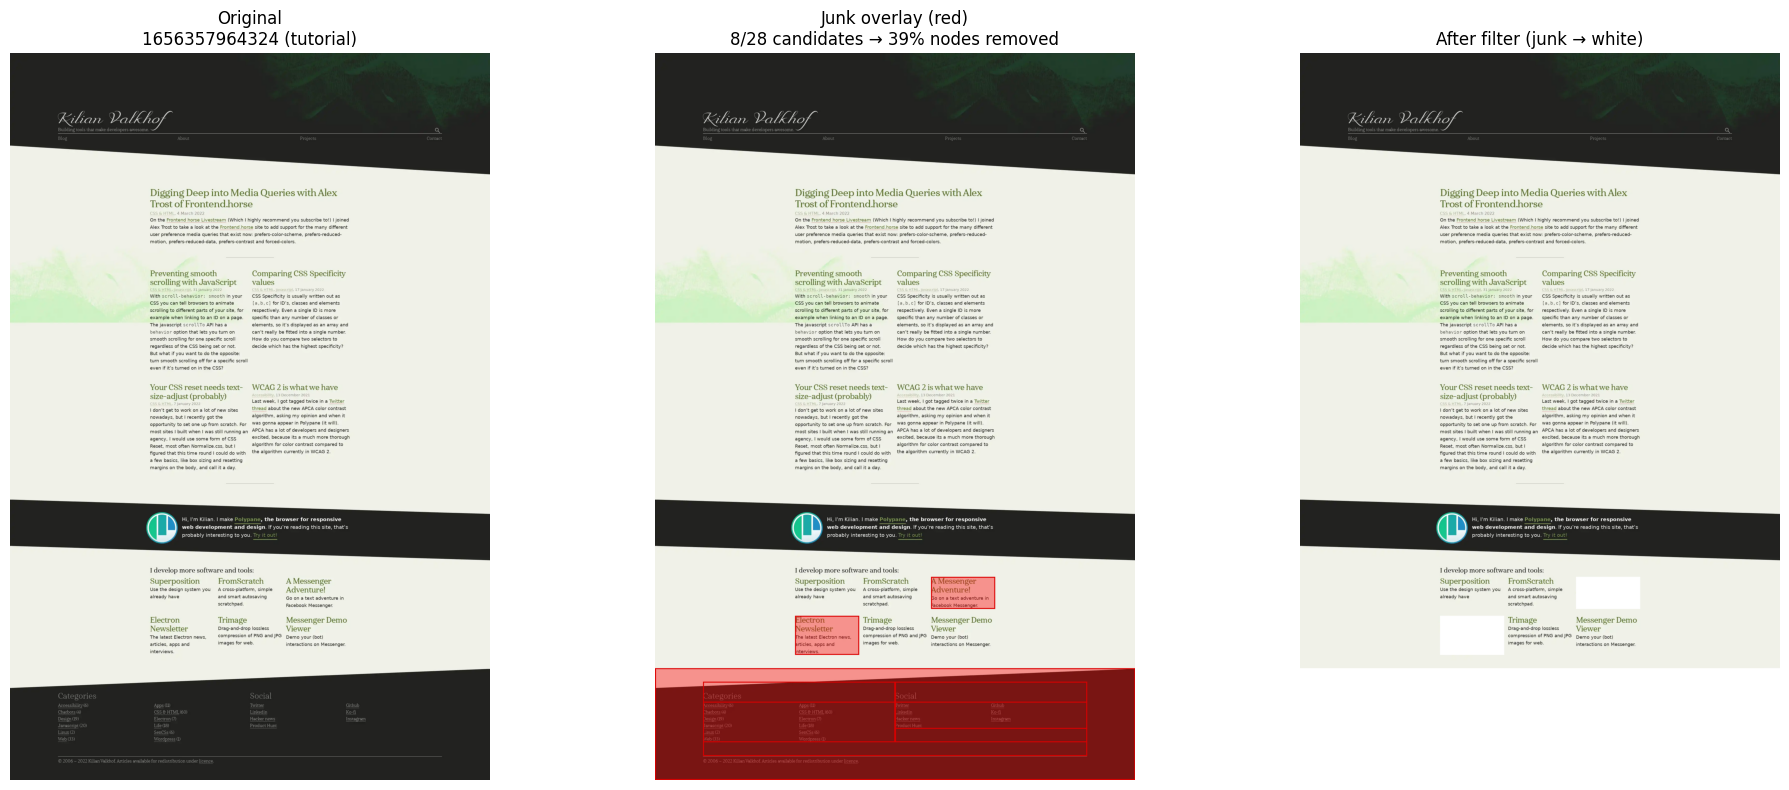

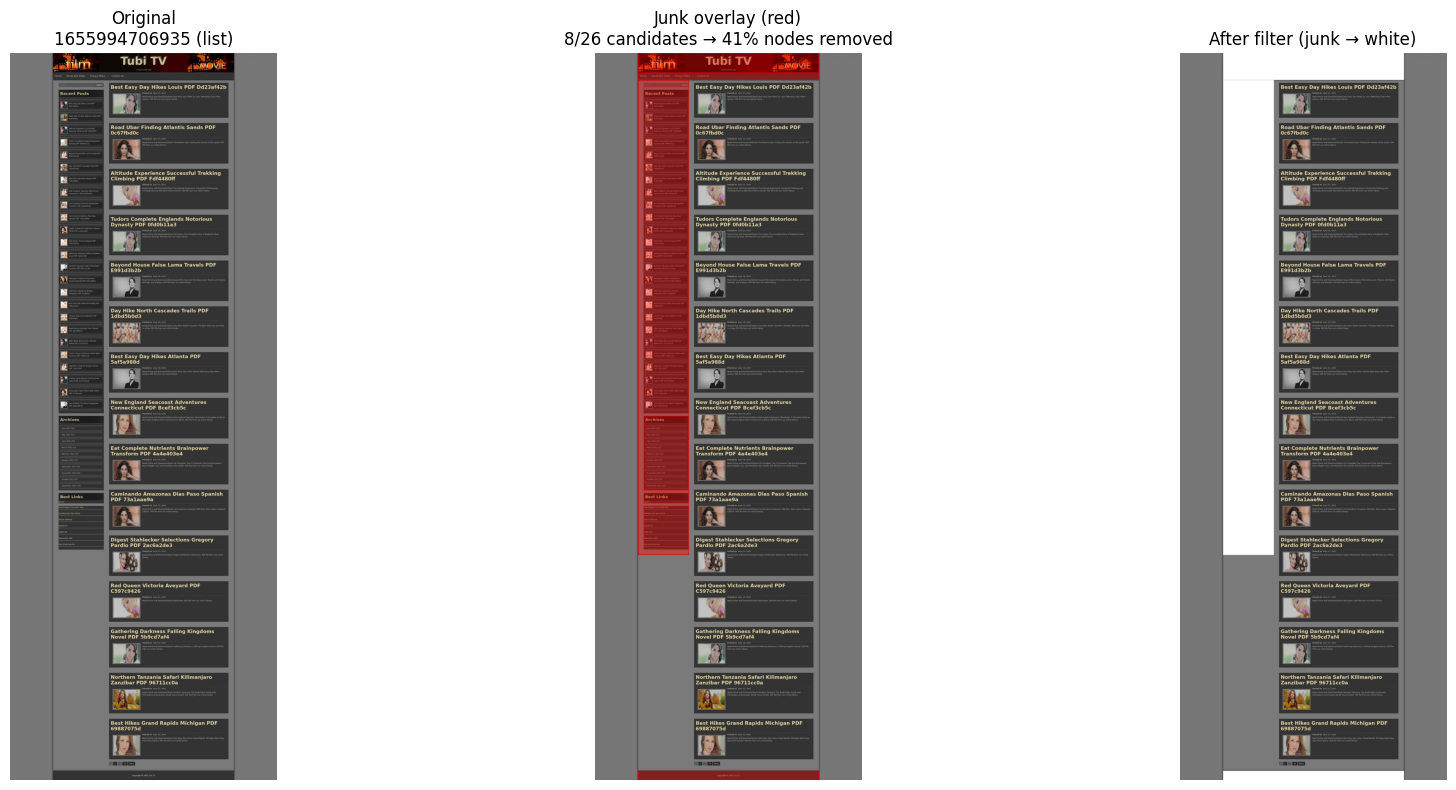

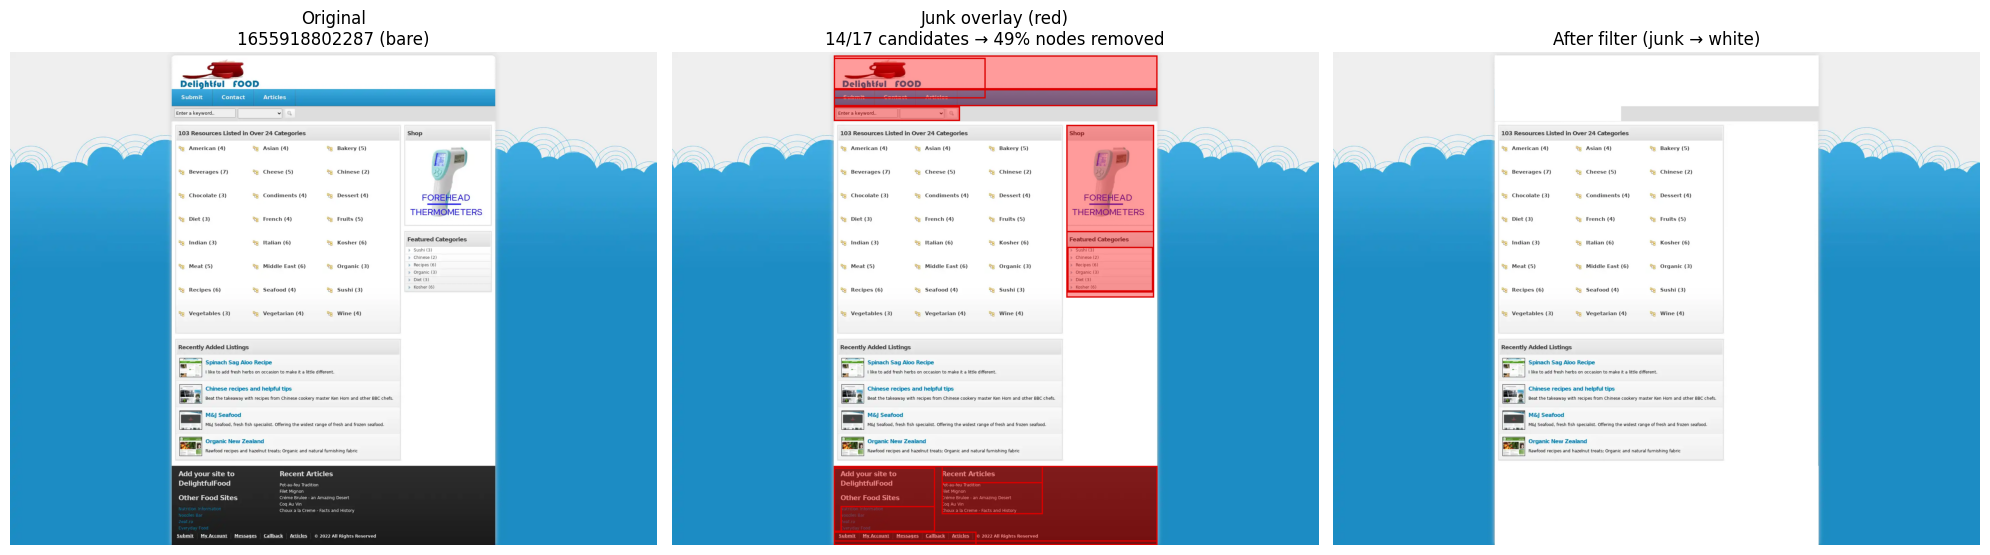

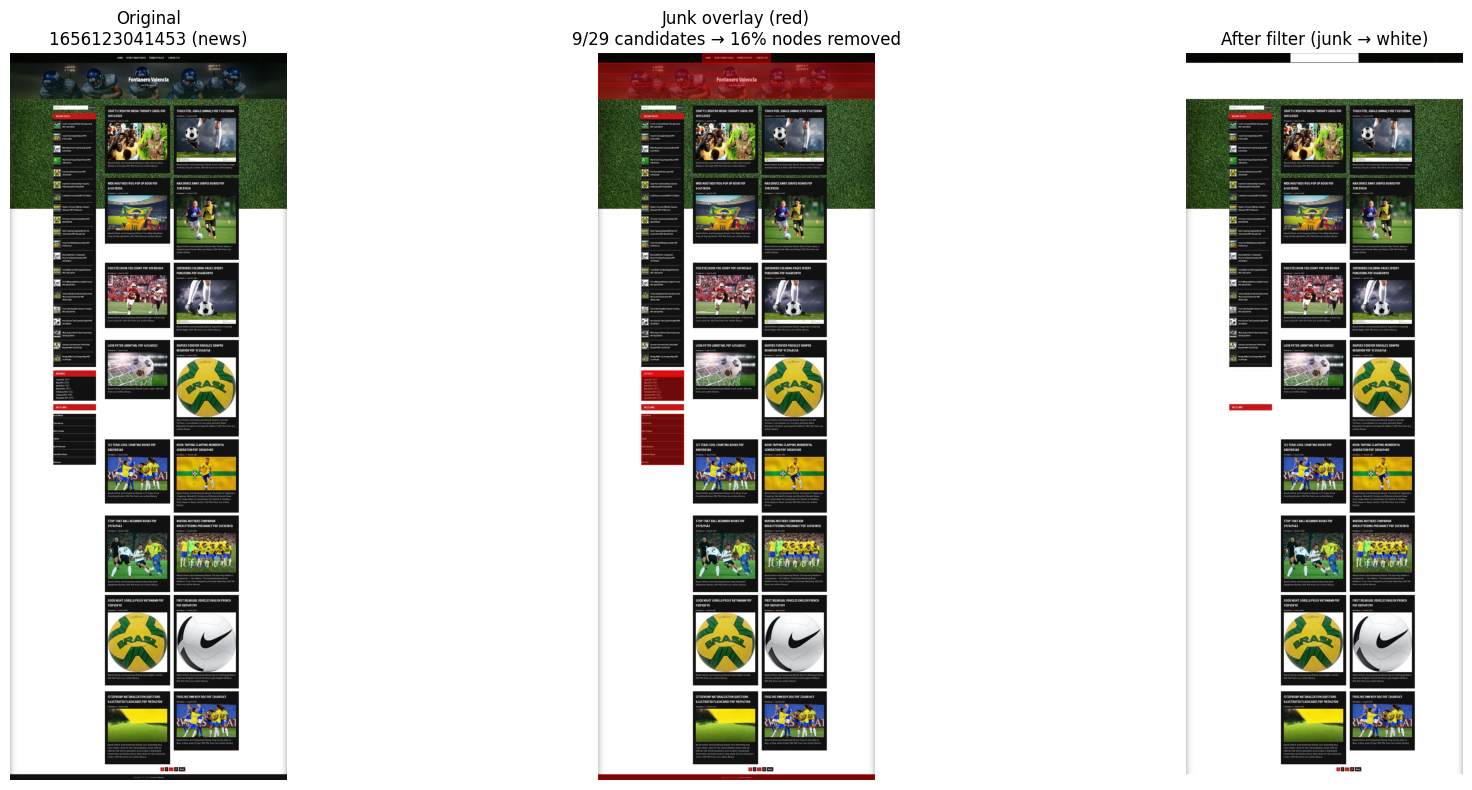

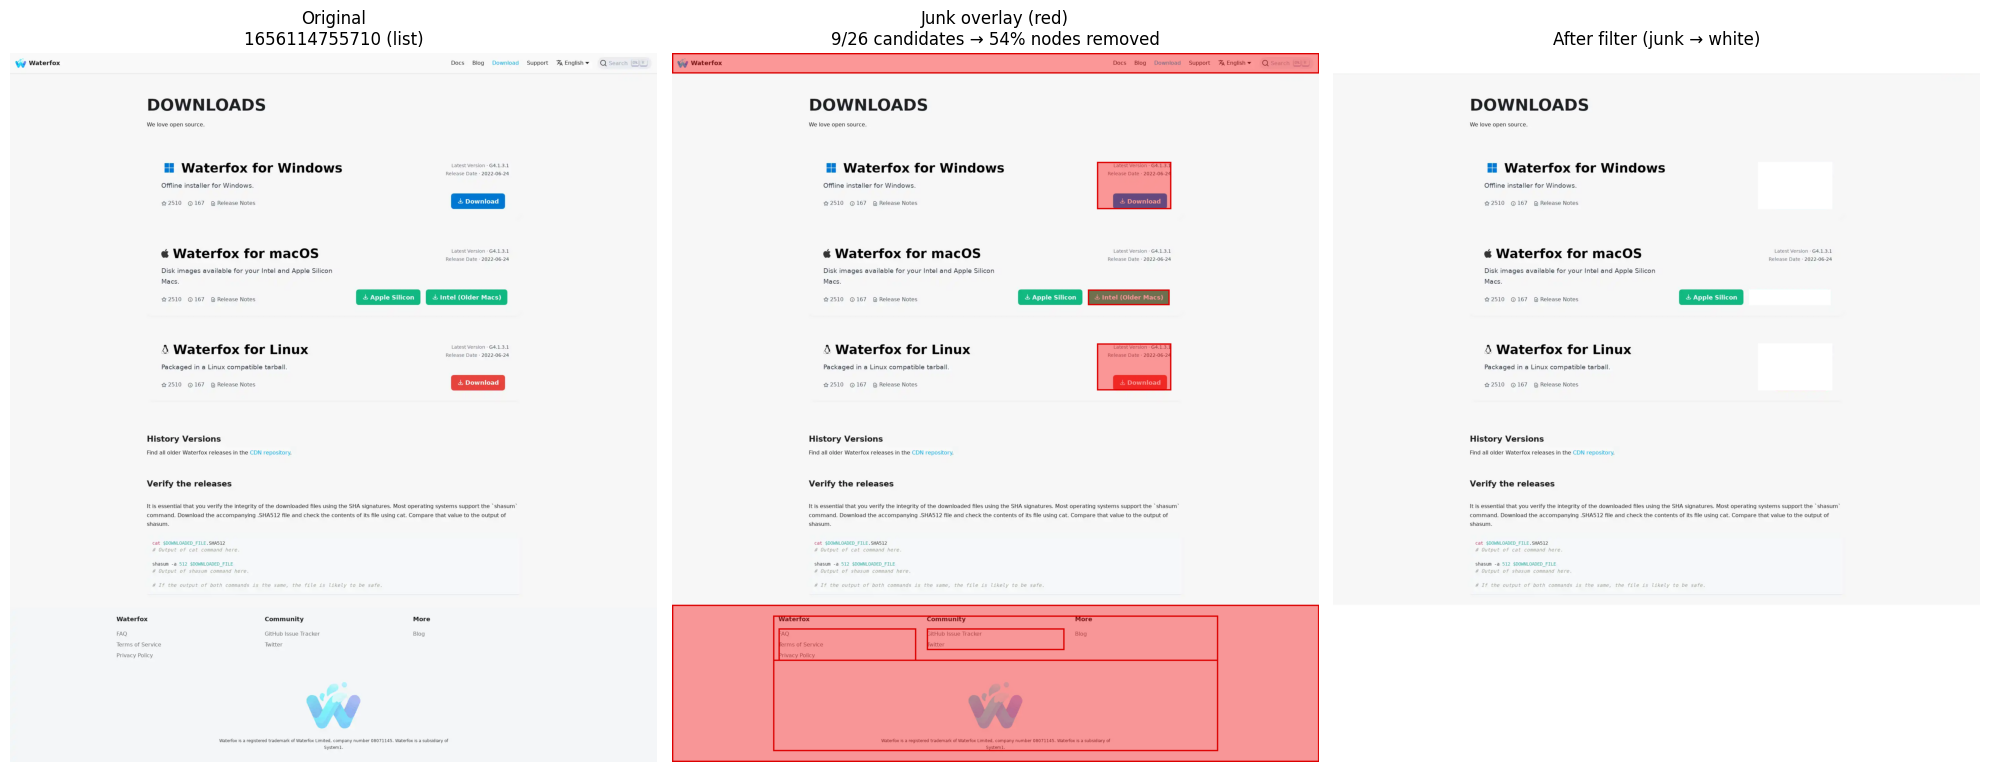

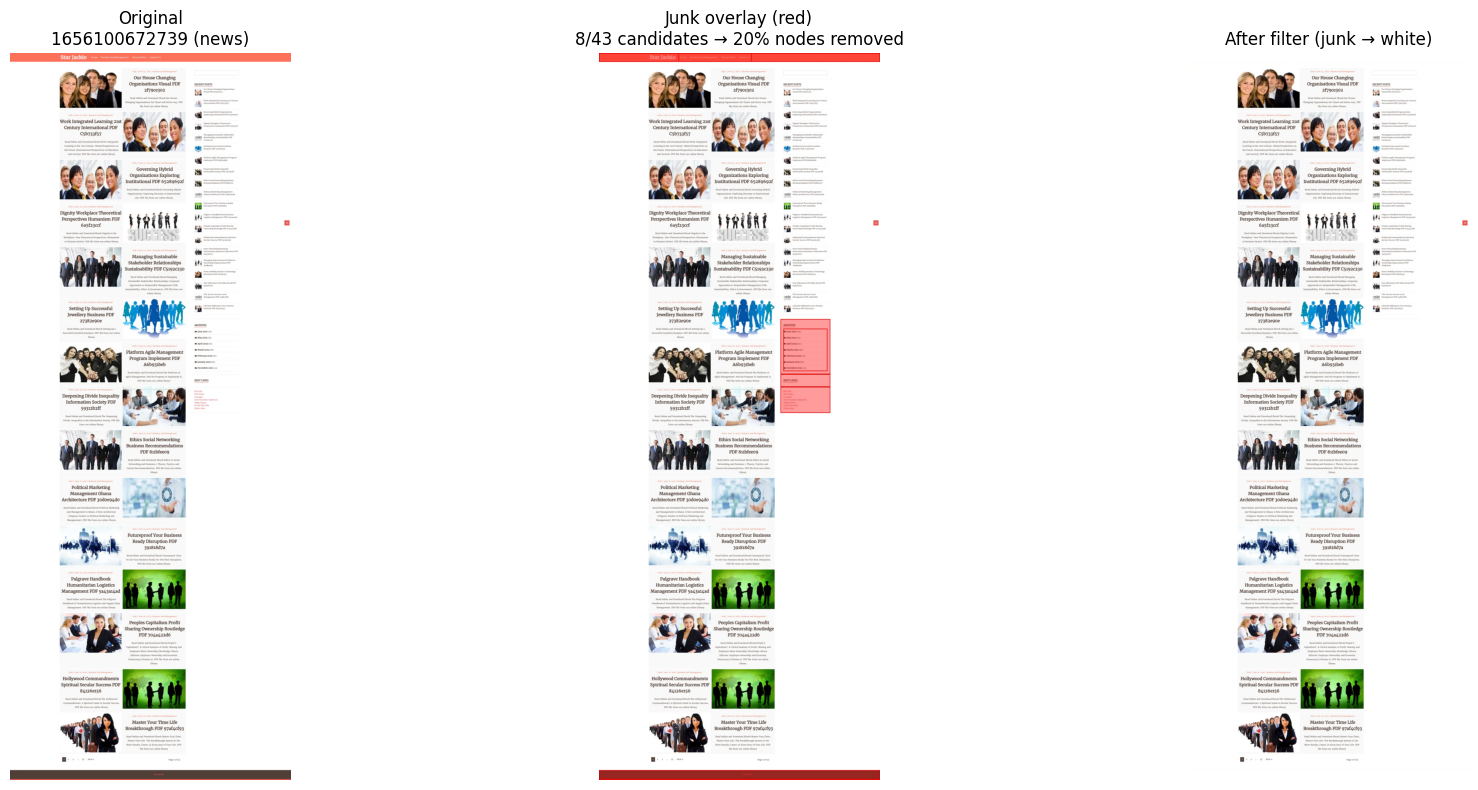

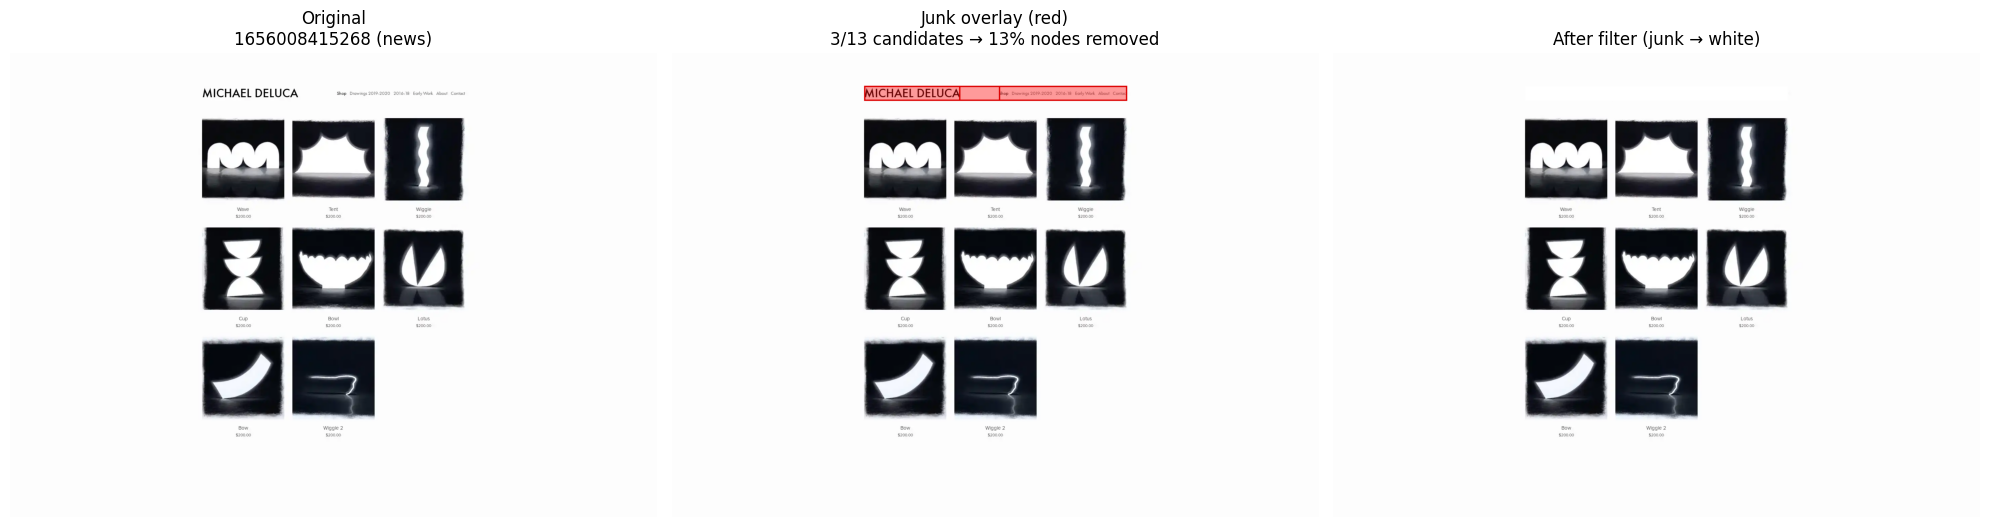

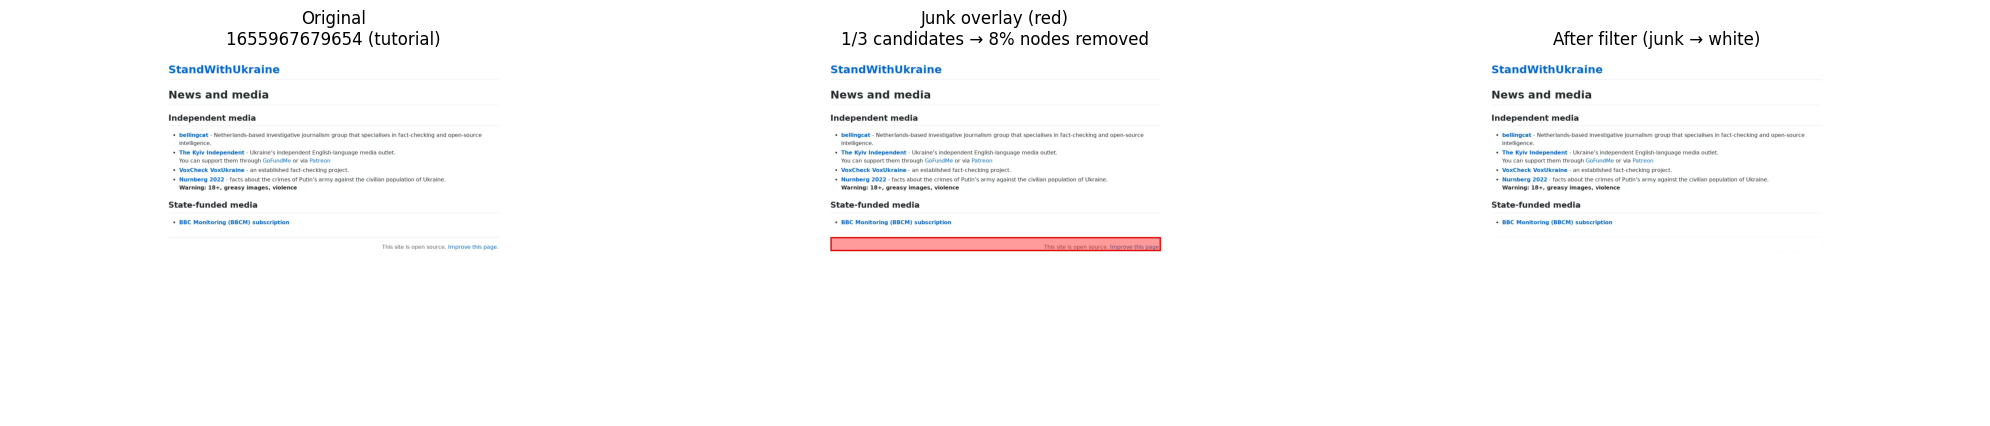

In [22]:
import random
random.seed(42)
demo_pages = random.sample([r for r in all_results if r['compression']['n_junk_candidates'] > 0], min(8, len(all_results)))

for r in demo_pages:
    page_dir = r['ax_data']['page_dir']
    screen_path = fa.find_screenshot(page_dir)
    if screen_path is None:
        continue
    img = Image.open(screen_path).convert('RGB')
    junk_bboxes = [p['candidate']['bbox'] for p in r['predictions'] if p['predicted_junk']]
    overlay = fv.shade_regions(img, junk_bboxes, color=(255, 0, 0), alpha=100)
    overlay = fv.draw_outlines(overlay, junk_bboxes, color=(220, 0, 0), width=4)
    masked = fv.mask_regions(img, junk_bboxes, fill_color=(255, 255, 255), alpha=255)

    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    axes[0].imshow(img); axes[0].set_title(f'Original\n{r["page_id"]} ({r["topic"]})'); axes[0].axis('off')
    axes[1].imshow(overlay)
    n_junk = r['compression']['n_junk_candidates']
    n_total = r['compression']['n_total_candidates']
    cr = r['compression']['compression_ratio']
    axes[1].set_title(f'Junk overlay (red)\n{n_junk}/{n_total} candidates → {cr*100:.0f}% nodes removed')
    axes[1].axis('off')
    axes[2].imshow(masked); axes[2].set_title(f'After filter (junk → white)'); axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(STATS_DIR / f'demo_{r["page_id"]}_3panel.png', dpi=80, bbox_inches='tight')
    plt.show()

## 8. Extreme cases — highest / lowest compression

In [23]:
sorted_results = sorted(all_results, key=lambda r: -r['compression']['compression_ratio'])
print('Top-5 pages with HIGHEST compression (most aggressively filtered):')
for r in sorted_results[:5]:
    print(f'  {r["page_id"]} ({r["topic"]}): {r["compression"]["compression_ratio"]*100:.1f}% '
          f'({r["compression"]["n_removed_nodes"]}/{r["compression"]["n_total_nodes"]} nodes)')

print('\nTop-5 pages with LOWEST compression (least filtered):')
for r in sorted_results[-5:]:
    print(f'  {r["page_id"]} ({r["topic"]}): {r["compression"]["compression_ratio"]*100:.1f}% '
          f'({r["compression"]["n_removed_nodes"]}/{r["compression"]["n_total_nodes"]} nodes)')

# Save extreme cases list
extreme = {
    'top_5_highest': [{'page_id': r['page_id'], 'topic': r['topic'],
                       'compression': r['compression']['compression_ratio']}
                      for r in sorted_results[:5]],
    'top_5_lowest': [{'page_id': r['page_id'], 'topic': r['topic'],
                      'compression': r['compression']['compression_ratio']}
                     for r in sorted_results[-5:]],
}
with open(STATS_DIR / 'extreme_pages.json', 'w', encoding='utf-8') as f:
    json.dump(extreme, f, ensure_ascii=False, indent=2)

Top-5 pages with HIGHEST compression (most aggressively filtered):
  1656316220146 (list): 99.9% (1598/1600 nodes)
  1655962938746 (tutorial): 99.7% (708/710 nodes)
  1656147480603 (tutorial): 96.8% (675/697 nodes)
  1656228376150 (tutorial): 94.0% (47/50 nodes)
  1655956773570 (tutorial): 86.6% (200/231 nodes)

Top-5 pages with LOWEST compression (least filtered):
  1656088601188 (tutorial): 10.4% (23/222 nodes)
  1655967679654 (tutorial): 7.8% (5/64 nodes)
  1655948417319 (news): 6.4% (37/581 nodes)
  1655885421832 (tutorial): 4.3% (109/2547 nodes)
  1656251547372 (list): 1.6% (12/728 nodes)


## 9. Visual: highest compression pages

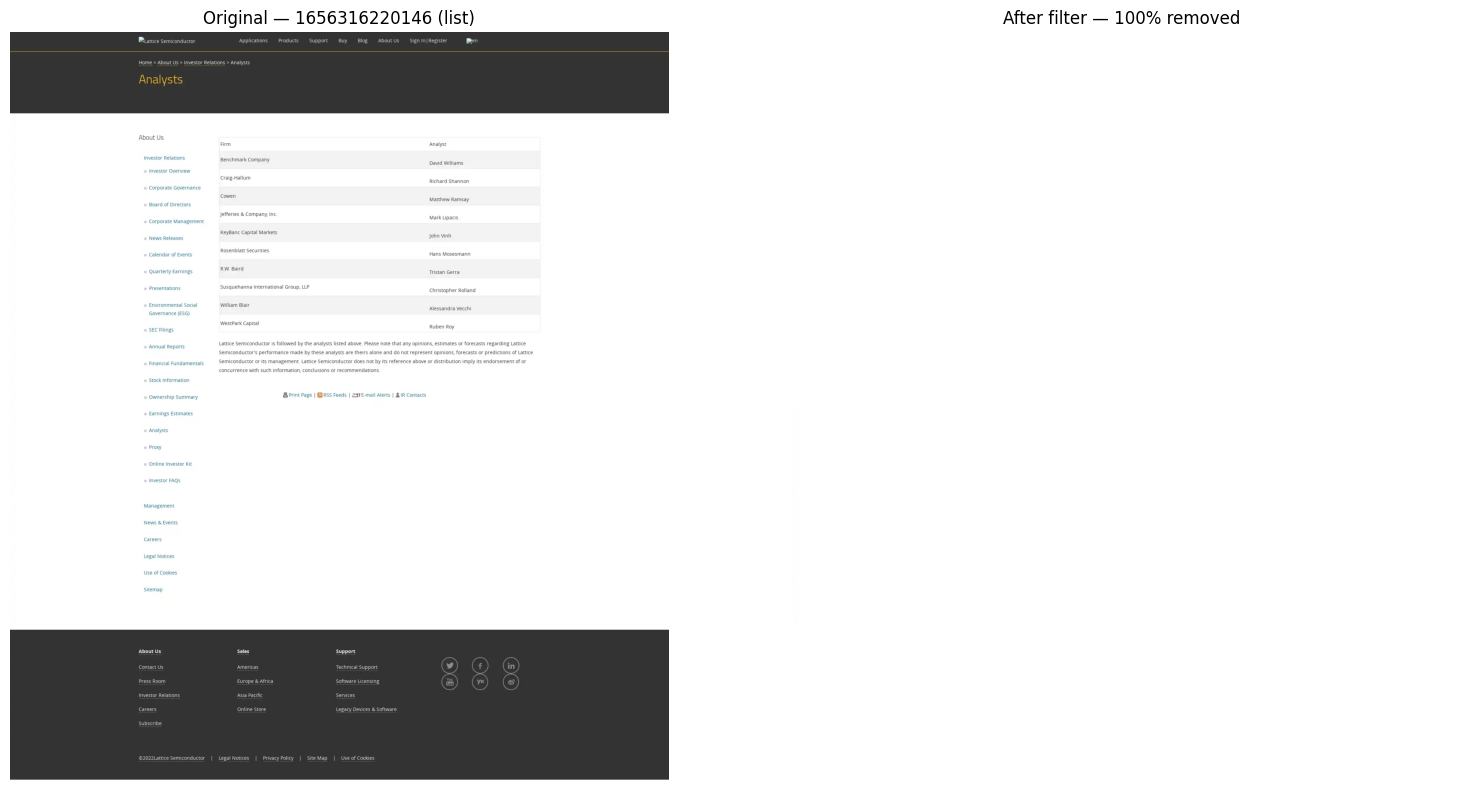

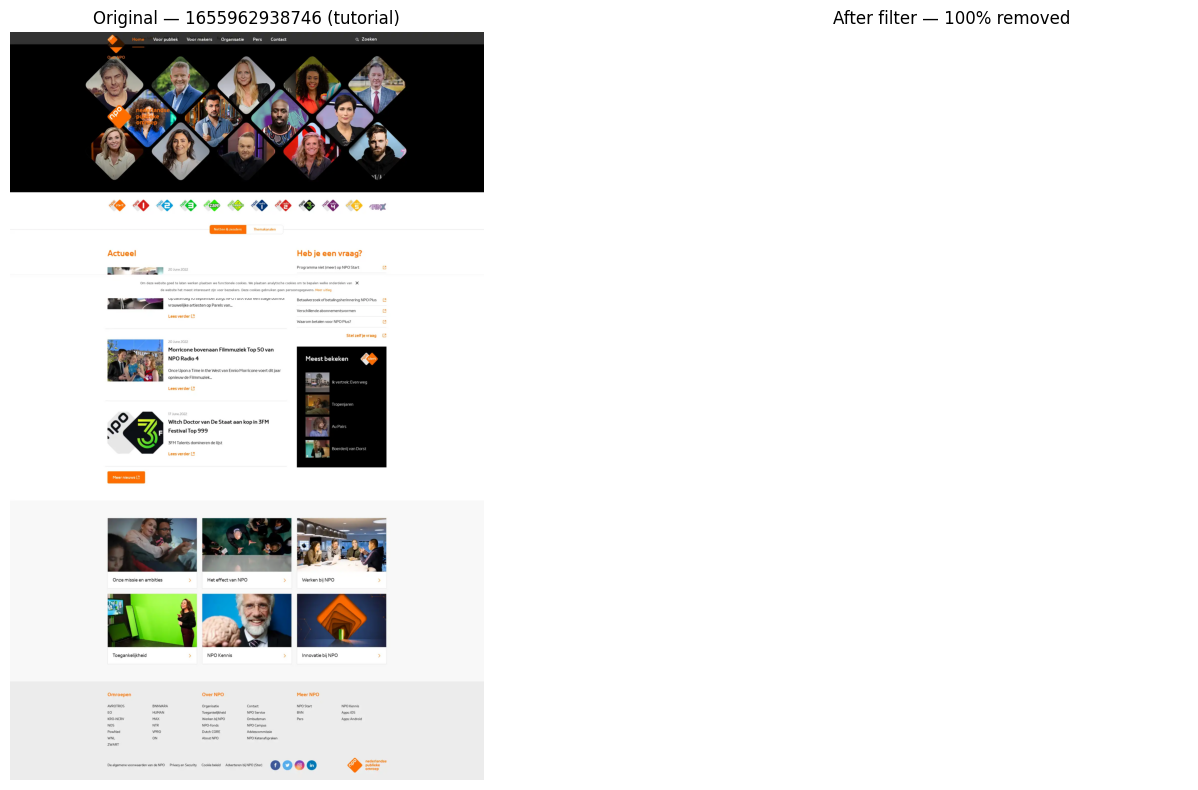

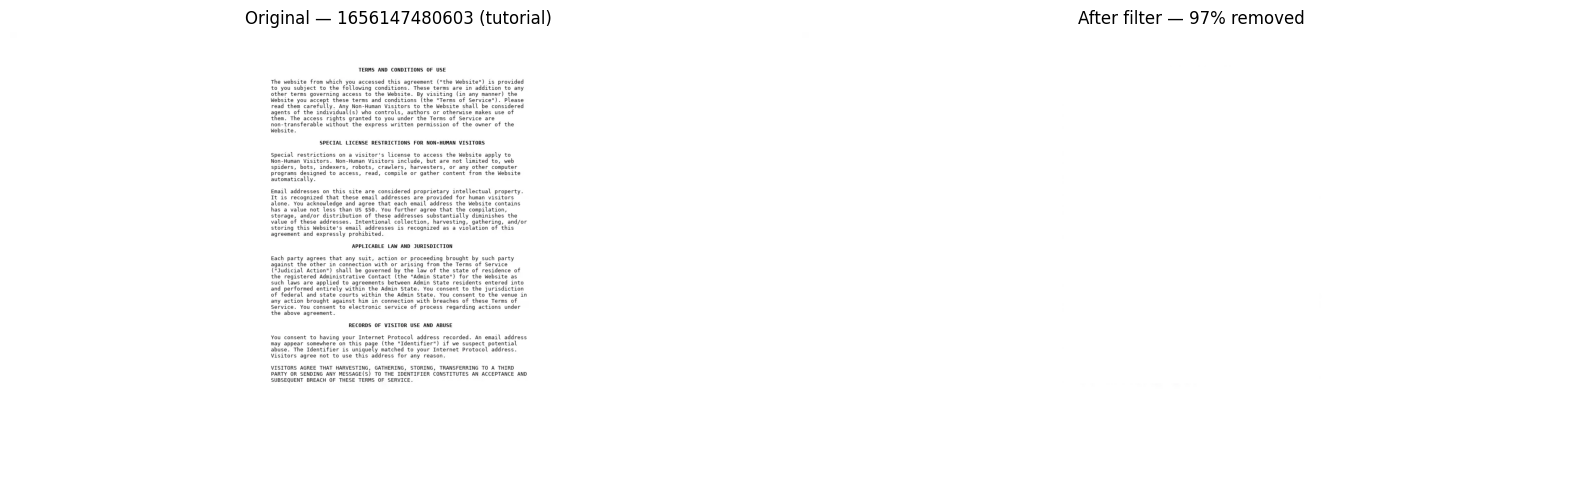

In [24]:
for r in sorted_results[:3]:
    page_dir = r['ax_data']['page_dir']
    screen_path = fa.find_screenshot(page_dir)
    if screen_path is None: continue
    img = Image.open(screen_path).convert('RGB')
    junk_bboxes = [p['candidate']['bbox'] for p in r['predictions'] if p['predicted_junk']]
    masked = fv.mask_regions(img, junk_bboxes)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(img); axes[0].set_title(f'Original — {r["page_id"]} ({r["topic"]})'); axes[0].axis('off')
    axes[1].imshow(masked)
    axes[1].set_title(f'After filter — {r["compression"]["compression_ratio"]*100:.0f}% removed')
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(STATS_DIR / f'highest_{r["page_id"]}_2panel.png', dpi=80, bbox_inches='tight')
    plt.show()

## 10. Visual: lowest compression pages

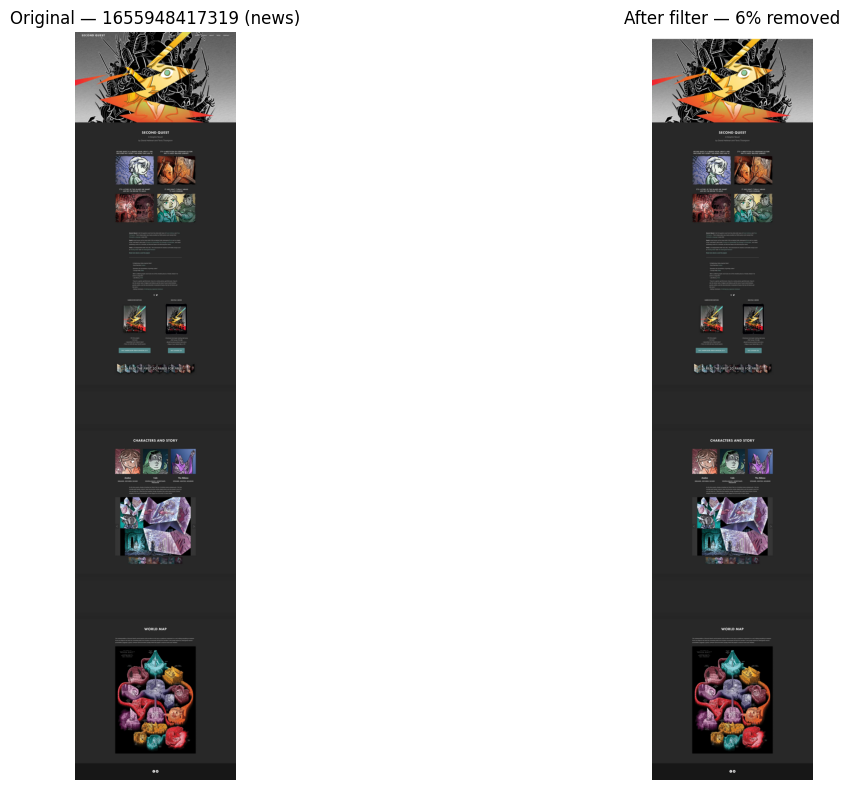

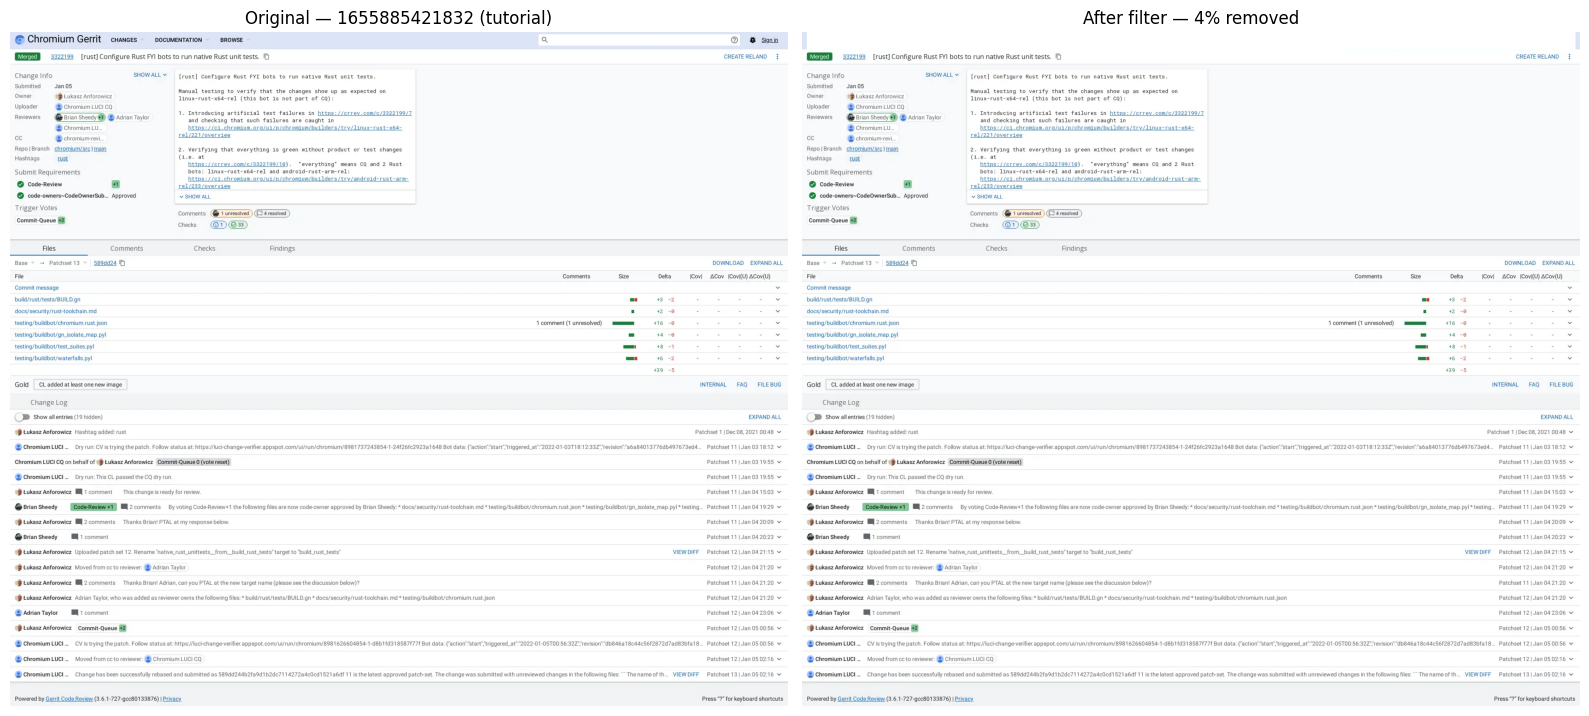

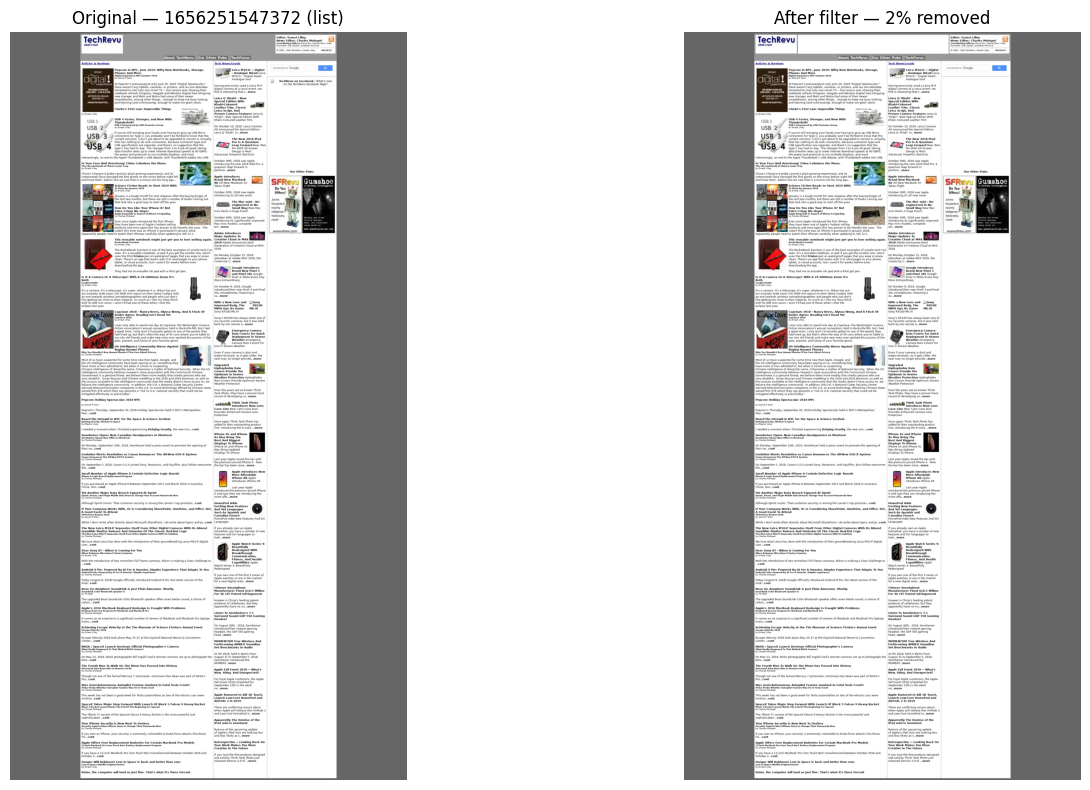

In [25]:
for r in sorted_results[-3:]:
    page_dir = r['ax_data']['page_dir']
    screen_path = fa.find_screenshot(page_dir)
    if screen_path is None: continue
    img = Image.open(screen_path).convert('RGB')
    junk_bboxes = [p['candidate']['bbox'] for p in r['predictions'] if p['predicted_junk']]
    masked = fv.mask_regions(img, junk_bboxes)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(img); axes[0].set_title(f'Original — {r["page_id"]} ({r["topic"]})'); axes[0].axis('off')
    axes[1].imshow(masked)
    axes[1].set_title(f'After filter — {r["compression"]["compression_ratio"]*100:.0f}% removed')
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(STATS_DIR / f'lowest_{r["page_id"]}_2panel.png', dpi=80, bbox_inches='tight')
    plt.show()

## Summary

Все картинки сохранены в `notebooks/webui/training/figures/`:
- `per_page/` — 3 PNG на страницу × 42 страницы = ~126 файлов (full resolution PIL)
- `comparisons/` — 3-way side-by-side per page (~42 файла)
- `stats/` — гистограммы compression, demo plots, JSON со статистикой